### Manual Round 3

**RULES**
You trade against a secret number of counterparties that all have a reserve price ranging between 670 and 920. You trade at most once with each counterparty. On the next trading day, you’re able to sell all the product for a fair price, 920. The distribution of the bids is uniformly distributed at increments of 5 between 670 and 920 (inclusive on both ends). 

You may submit two bids. If the first bid is higher than the reserve price, they trade with you at your first bid. If your second bid is higher than the reserve price of a counterparty and higher than the mean of second bids of all players you trade at your second bid. If your second bid is higher than the reserve price, but lower than or equal to the mean of second bids of all players, the chance of a trade rapidly decreases: you will trade at your second bid but your PNL is penalised by:

$$(\frac{920 - avg_{b2}}{920-b_2})^3$$


In [73]:
#No of buckets in the distribution
print((920-670) /5 + 1)

51.0


Since the bids (asks) are uniformly distributed and no other information is given about the reserve price my interpretation of the official prosperity rules above is that:

- Reserve prices are uniformly distributed. As such we assume same quantities/probabilities for every reserve price. 
- If our first bid is higher than a counterparties reserve price, we trade with that counterparty.

So for BID 1:
- IF B1 >= reserve price -> we buy at price B1, this applies to all the quotes in the "orderbook". So placing a high bid say 900 will allow us to trade with everyone at or below 900 which would be 46/51 total reserve price buckets (51 buckets between 920 and 670). We would execute all trades at 900. 

- ELSE IF B2 >= reserve price -> we buy at price B2 but we incur a penalty. Let AVG_B2 be the average of all players bids on the competition. For a trade that happens via the second bid:
    - IF B2 > AVG_B2 -> we pay exactly B2 for that trade. 
    - IF B2 <= AVG_B2 -> we pay B2 but PnL on the trade is multiplied by the multiplier. 

Since the volumes at each level of reserve prices are the same, we do not need to account for volumes as a variable in the maximization problem, it is rather a given constant that scales any PnL equally. What we need to maximize in the volume sense is the no. of buckets we trade with. 

Our optimization for B1:
$$PnL = (920 - B1) * [(B1 - 670) / 5 + 1]$$

Note +1 since inclusive. For example if our bid is 680 we trade with 670, 675 and 680. So 680 - 670 = 10, 10 / 5 = 2, 2 + 1 = 3
Now for B2 we wont trade with counterparties we already traded at during B1.

For B2:
$$PnL = (920 - B2) * [Buckets B2 \setminus Buckets B1] * E[\text{Penalty Multiplier}]$$

Then:
$$E[\text{Penalty Multiplier}] = F(B2) \cdot (\frac{920-AVG_{B2}}{920-B2})^3$$

So we can see that B1 price should by construction be lower than B2, B2 < B1 does not make any sense since for B2 we only trade with counterparties not previously traded with, so if B2 < B1 then B2 doesn't generate any new trades. We could start by maximising B1 for its interior optimal just to get a feel but the final expression needs to be a joint expression.





Also let's simplify the penalty notation by just using the expected mean value directly. Our joint expression for PnL: 

$$EV[B_1, B_2] = (920-B_1) * [\frac{B_1-670}{5} + 1] + (920 - B_2) * (\frac{B_2-B_1}{5}) * m(B_2)$$

Where:
$$m(B_2) =  \begin{cases} 1 & B_2 > \mu \\ \left( \frac{920 - \mu}{920 - B_2} \right)^3 & B_2 \leq \mu \end{cases}$$

Note the B2-B1 section uses our assumption B2 > B1 otherwise the B2 condition does not result in any trades. So if B2 = 900 and B1 = 800 B2-B1 = 100 then divide by 5 we get 20 buckets. Note not 21 since we cannot trade with the same party twice so it is not inclusive on the right for B2 trades since B1 covers that trade. 

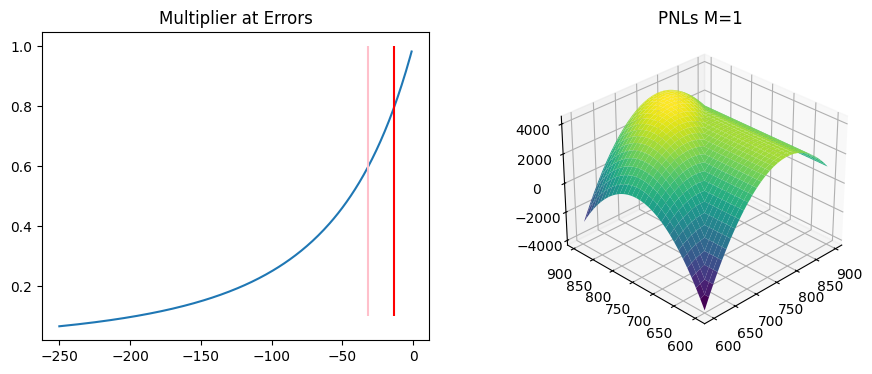

OPTIMAL B1, B2 (m=1): 750, 835


In [74]:
import matplotlib.pyplot as plt
import numpy as np

#error sim
mean = 750
bids = np.arange(500, 750, 1)
errors = bids - mean

def multi(mean, bid):
    return ((920-mean)/(920-bid))**3

multipliers = multi(mean, bids)

#assuming m=1
b1s = np.arange(600,900, 5)
b2s = np.arange(600,900, 5)
B1, B2 = np.meshgrid(b1s, b2s)

def pnl(b1, b2):
    leg1 = (920-b1)*((b1-665) / 5)
    leg2 = (920-b2)*((b2-b1) / 5)
    return np.where(b2>b1, leg1+leg2, leg1)

pnls = pnl(B1, B2) 

fig =  plt.figure(figsize=(11,4))
ax0 = fig.add_subplot(1, 2, 1)               
ax1 = fig.add_subplot(1, 2, 2, projection='3d')  

ax0.set_title("Multiplier at Errors")
ax0.plot(errors, multipliers)
ax0.vlines(-13.126948652710098, 0.1, 1, color="red")
ax0.vlines(-31.557287254436915, 0.1, 1, color="pink")

ax1.set_title("PNLs M=1")
ax1.plot_surface(B1, B2, pnls, cmap="viridis")
ax1.view_init(elev=30, azim=225)

plt.show()

#found via derivatives
print("OPTIMAL B1, B2 (m=1): 750, 835")

**B2 Dynamics**
The penalty is kinda IMC telling us to be risk averse since the penalty multiplier is extreme. See the chart below that shows what the multiplier will be for each "error" that one falls under the mean, I assume a mean for simplicity. IF mean = 750 then an error of just 13 to the bid AVG is a m = 0.8, if the error is 31 m = 0.6, if error is 50 m < 0.5. 

What this means is PnL terms:
- IF B2 a bit above avg B2 -> multiplier equals one. We sacrifice maybe 10-40 units of profit per trade to secure this.
- IF B2 a bit below avg B2" -> problematic. As stated even just being 30 below will wipe out 40% of profits from B2 trades.
- IF B2 far above avg B2 -> overpays a lot (ofc)

Point being that best EV B2 bid is going to skewed towards safety, most other participants will probably also realise this. I considered a bunch of mathematical ways of "modelling" the mean B2 but then realised that this will just create a completely illusory modeling excercise where we optimze B2, B1 to some insane Monte-Carlo sim that will end up being innaccurate. 

As prev teams have done, best way is prob to make some empirical notes and then make assumptions about the mean and then run a monte carlo on that. Assumptions:

### Leaderboard Data ###
Its unclear how many teams exist from the leaderboards but pages went from 221 -> 41. The 200K limit was not that high but will likely have sorted away most very unserious actors, however a pretty decent chunk of "clueless" teams exist. Likely circa 20-25% judging by PnL data from R1 and discord sentiment. However these actors are unlikely to affect the mean that much.

### Discord ###
Some sentiment analysis suggests that people are expeting to bid 800-900, even if most people are joking/lying these claims still hold value underneath. People would if anything try and state lower numbers than their actual bids to sanbag the competition. Real range is likely 820-880. 

### A non-trivial amount of users will use LLMs for their predictions ###
Claude suggested a high range round 850-870 for example, a chunk of users will do the same and more or less go off exactly what the AI tells them to do. I asked multiple other agens as well:
- Grok: 860
- Gemini: 860
- ChatGTP: 900 
- DeepSeek: 835 (reasoned similary as I did regarding the Pareto Efficient NA)

### "Mathematical" Nash Equilibria ###
A common assumption made by prev successfull teams was that a certain amount of players will play according to a NE and some one lvl below the NE and some 2 lvls below. If we isolate the optimal bid for the first B1 independently that is 790 and 795 are equally good and yield a profit of 3250. Since this is very easily computed, we'd assume that basically all semi-serious and serious actors know this. Now for B2 to make sense B2 > B1 by at least 5. We get a lower bound of around 800. A smaller percentage of the player base who are noobs/dont have time will go off this alone and then just pick B2 based on vibes. 

However a large chunk of players are likely smarter than this and will notice that if we assume that the multiplier is 1 then the optimal solution is B1=750, B2=835. The NE of the game is technically speaking these two exact bids of 750 and 835 since if all players submit these bids no players can improve by deviating. 

- BIDDING < 835: The penalty kicks-in. The penalized payoff is striclty increase from below 835 to 835.
- BIDDING > 835: Gives the no penalty payoff which is strictly decreasing after 835. 

Since 750, 835 is the global maxmimum, this NE is pareto efficient. 750, 835 is individually rational and collectively maximal, not even a coordinated equilibrium could achieve higher utility so it is pareto efficient, we cannot make anyone better off without making anyone else worse-off. If this were rational individuals trading with real money then the players should converge here. 

However, prosperity is paper money and a winner-takes all dynamic. If everyone gets the same PnL as everyone else then that is less utility than if you get 1 more PnL then everyone else. However at the same time the utility is not purely ranked based because this is just one of several trading rounds and the final winner is decided by total PnL.

Importantly, sophisticated players know that bidding above μ is much safer than below. This creates an positive reinforcment "loop": each layer of "meta"-reasoning pushes the mean higher. Some players will be 1 "meta" level above the normal NE, some will be 2 levels etc. The question here is, can we calculate where the marginal cost of safety equals the marginal utility of safety+

### Nonserious actors ###
Unlikely to impact the avg that much since they skew both ways but approx. 10% of actors will probably not submit at all or submit at random/irrational. As said this likely distributes relatively evenly around the mid with a slight Skew however to the left. Reason being that since the true mean is likely around 800-850 if we assume unserious actors are just as likely to pick stupidly low and high numbers then the low picks will have a greater impact on the mean, a 100 moves the mean more from 800-850 range than 900.

### Numbers theory ###
Since the mean is likely between 800-900 people will gravitative towards round nice numbers that feel high and secure such as 850 and 900. 900 somehow feels a lot safer than 890. 



I told Claude to search online and make its best guesstimate of how people would bid via the reasoning above and then i adjusted slightly. 

| Group | Share | Bid | Contribution to μ |
|-------|-------|-----|-------------------|
| Pareto-NE players | 15% | 835 | 125 |
| Risk-averse near-NE | 25% | 845-855 | 213 |
| LLM-followers (modal) | 20% | 860 | 172 |
| Round-number 900 | 15% | 900 | 135 |
| Round-number 850 | 10% | 850 | 85 |
| Clueless/random | 10% | ~795 | 80 |
| High & safe (910+) | 5% | 910 | 46 |
| **Weighted μ** | **100%** | | **~856** |

Note for clueless random we make the argument that they will be lower than the mean by some margin, since they just go off vibes their guesses are likely distributed between 500-600 and 900 instead of the tighter 800-900 range. 

Now if we assume a mean of 855 for simplicity we can plot the Marginal Utility of Safety vs the Marginal Cost. First we must calculate what the optimal B1 is assuming that B2 would be a tiny bit above 855 so that we are actually fitting to our strategy params. 

Assuming B2 = 870 -> optimal B1 = 765 and 770

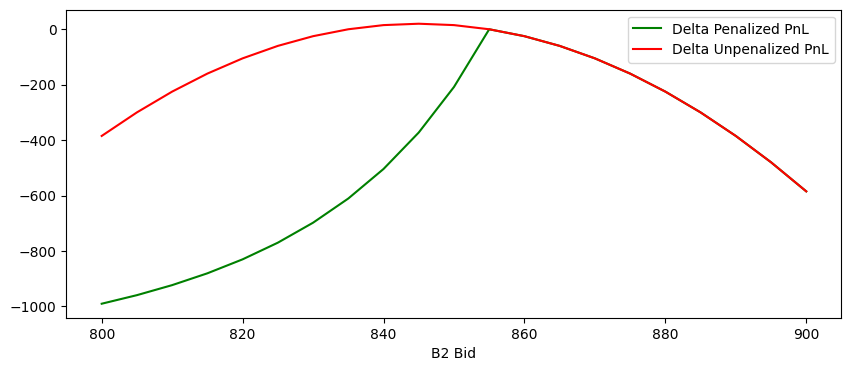

20.0


In [75]:
#assumes our base strategy is 765, 770 and that we know that the mean is 855, then looks at how does the 
#penalty cost us at levels a bit below 855 vs what we gain and vice versa.

mean = 855
bids1 = 770
bids2 = np.arange(800, 905, 5)

def penalty (bid):
    return np.where(bid >= mean, 1, ((920-mean) / (920-bid))**3)
    
def pnl(b1, b2):
    return (920-b2)*((b2-b1) / 5) #only second part of profit is penalized

utility = penalty(bids2) * pnl(bids1, bids2) - (920-855) * ((855-770)/5) #how much we avoid losing/lose total for each B2 (new Pnl - base Pnl)
based = ((bids2-bids1)/5 * (920-bids2)) - ((855-bids1)/5 * (920-855))  #how much Pnl is lost/gained by the B2 increase(decrease) delta buckets * delta pnl/bucket

fig, ax = plt.subplots(1, 1, figsize=(10,4))
ax.plot(bids2, utility, color="green", label="Delta Penalized PnL")
ax.plot(bids2, based, color="red", label="Delta Unpenalized PnL")
ax.set_xlabel("B2 Bid")
ax.legend()

plt.show()
print(max(based))

What the above shows is that given our planned B1 = 770 play (B1 isolated optimal is 790, 795 but jointly with a B2=855 or a bit higher it is 765, 770), the potential "gain" of trying to be as low as possible below the expected mean of 855 is almost 0 compared to the expected loss from the penalty. After the mean, both functions will be strictly decreasing by desing at the same rate. What this conceptually "proves" is that we should aim for a high probability of securing 10 or so above the mean.


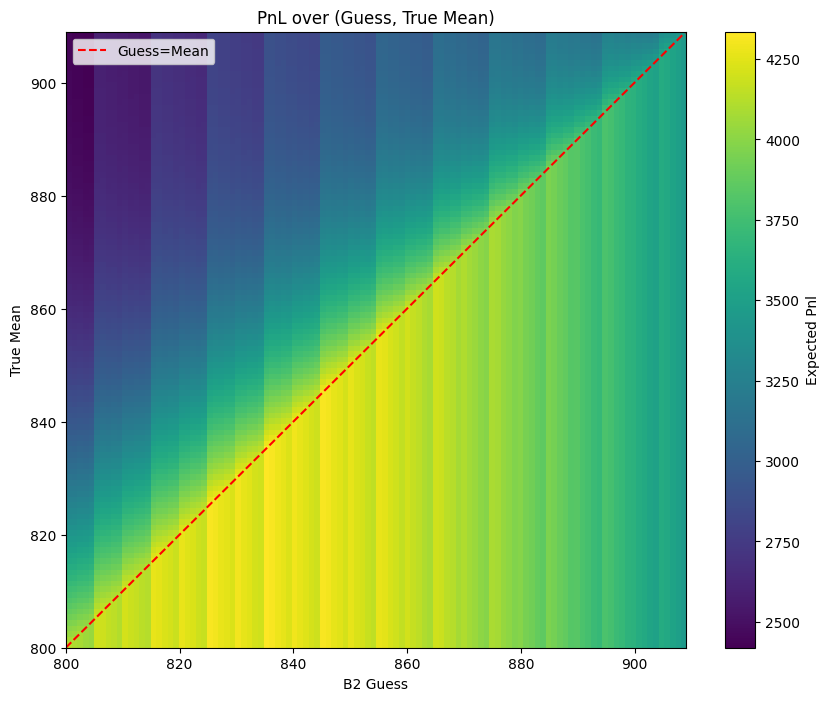

In [81]:
#simulate PnLs for different means and guesses:
guesses = np.arange(800, 910, 1)
true_means = np.arange(800, 910, 1)

G, M = np.meshgrid(guesses, true_means) #meshgrid 1A -> axis 1, 2A -> axis 0 so we get guesses = cols, means = rows

def optimal_b1(b2):
    return (332.5 + 0.5 * b2).astype(int)

def pen(b2, mu):
    return np.where(b2 >= mu, 1, ((920-mu)/(920-b2))**3)

def pnl(b1, b2, mu):
    n1 = np.floor((b1-665) / 5).astype(int)
    n2 = np.floor((b2-665) / 5).astype(int) - n1
    return (920-b1) * n1 + (920-b2) * n2 * pen(b2, mu)

B1 = optimal_b1(G)
pnls = pnl(B1, G, M)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
im = ax.imshow(pnls, 
            origin="lower", 
            extent=(guesses.min(), guesses.max(), true_means.min(), true_means.max()),
            aspect="auto",
            cmap="viridis")

ax.set_xlabel("B2 Guess")
ax.set_ylabel("True Mean")
ax.set_title("PnL over (Guess, True Mean)")

ax.plot([guesses.min(), guesses.max()], [true_means.min(), true_means.max()], "--r", label="Guess=Mean")

plt.colorbar(im, ax=ax, label="Expected Pnl")
ax.legend()
plt.show()

In [82]:
print(332.5+0.5*876)

770.5
